# 06 — 라벨 노이즈와 천장: 왜 모든 방법이 0.95 에서 멈추는가

앞의 다섯 노트북과 실험 다섯 개(7.1~7.5절)가 전부 **pooled AUC 0.9495~0.9500** 에서 멈췄다.
baseline 0.949605, 가중 앙상블 최고 0.949943, pseudo labeling 0.949614, lean 0.949699.
무엇을 해도 0.9500 을 못 넘는다. 이 노트북은 그 이유를 **데이터 생성 과정**에서 찾는다.

## 출발점 — 한 스터디원의 질문

> "합성 데이터니까 일부러 노이즈를 넣었을 텐데, 지금 노이즈를 빼고 학습하고 있지는 않잖아?
> 대략 5% 정도 같은데, 빼고 학습하면 더 단순한 모델로 좋은 성능이 나오지 않을까?"

`make_classification` 에는 `flip_y` 라는 인자가 있어서 **라벨의 일정 비율을 무작위로 뒤집는다.**
이 질문은 두 부분으로 나뉜다.
1. 노이즈가 정말 있는가, 얼마나 되는가? (진단)
2. 빼고 학습하면 좋아지는가? 더 단순한 모델이 따라잡는가? (실험)

## 이 노트북에서 배우는 것

| 주제 | 절 |
|---|---|
| **라벨 노이즈를 탐지하는 세 가지 방법** — 확신 오답의 임계값 둔감성, 혼합비 추정, 그룹 균일성 검정 | 2~4 |
| **지표의 천장을 계산하는 법** — 라벨 노이즈 f 가 있을 때 완벽한 분류기의 AUC 상한 | 5 |
| **합성 대조 실험** — 진짜 라벨을 아는 세계에서 모델의 진짜 성능을 재기 | 6 |
| **노이즈 제거 학습의 누수 없는 프로토콜과 결과** | 7 |
| **in-sample 캘리브레이션의 착시** — 노이즈에 과적합한 이득 | 8 |

읽는 데 필요한 산출물: `experiments/lean/`, `experiments/denoise/`, `experiments/calibrate/` 의 `outputs/`.
이 노트북은 재학습을 하지 않는다(몇 초).

In [1]:
import json
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from scipy import stats
from sklearn.metrics import roc_auc_score

PROJECT_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "loader.py").exists())
sys.path.insert(0, str(PROJECT_DIR))
from data.loader import get_data_dir

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
_available = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"):
    if _font in _available:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

EXP = PROJECT_DIR / "experiments"
def load_json(p):
    if not p.exists():
        raise FileNotFoundError(f"{p} 가 없습니다. README 3절의 실행 순서를 따라 먼저 생성하세요.")
    return json.loads(p.read_text(encoding="utf-8"))

diag = load_json(EXP / "denoise" / "outputs" / "diagnose_metrics.json")
synth_dn = load_json(EXP / "denoise" / "outputs" / "synthetic_metrics.json")
den = load_json(EXP / "denoise" / "outputs" / "denoise_metrics.json")
cal = load_json(EXP / "calibrate" / "outputs" / "lean_metrics.json")
lean_m = load_json(EXP / "lean" / "outputs" / "lean_metrics.json")
base_m = load_json(EXP / "baseline" / "outputs" / "baseline_metrics.json")

MAGIC_COL = "wheezy-copper-turtle-magic"
p = np.load(EXP / "lean" / "outputs" / "lean_oof_train.npy")
lab = pd.read_csv(get_data_dir() / "train.csv", usecols=["target", MAGIC_COL])
y = lab["target"].to_numpy(); magic = lab[MAGIC_COL].to_numpy()
order = np.argsort(magic, kind="stable"); bounds = np.searchsorted(magic[order], np.arange(513))
slices = [order[bounds[m]:bounds[m + 1]] for m in range(512)]
print(f"lean OOF: n={len(p):,}, pooled AUC={roc_auc_score(y, p):.6f}")

lean OOF: n=262,144, pooled AUC=0.949699


## 1. 먼저 그림 하나 — 라벨별 예측확률 분포

**무엇을 하나** — lean 의 OOF 확률을 정답 라벨별로 나눠 히스토그램을 그린다.

**왜 하나** — 라벨 노이즈가 있다면 **y=1 인데 p≈0 인 덩어리**와 **y=0 인데 p≈1 인 덩어리**가 보여야 한다.
모델이 "자신 있게 틀린" 행들이다. 진짜 모델 오류라면 경계 근처(p≈0.5)에 흩어져 있을 것이고,
뒤집힌 라벨이라면 **반대편 극단에 뭉쳐** 있을 것이다.

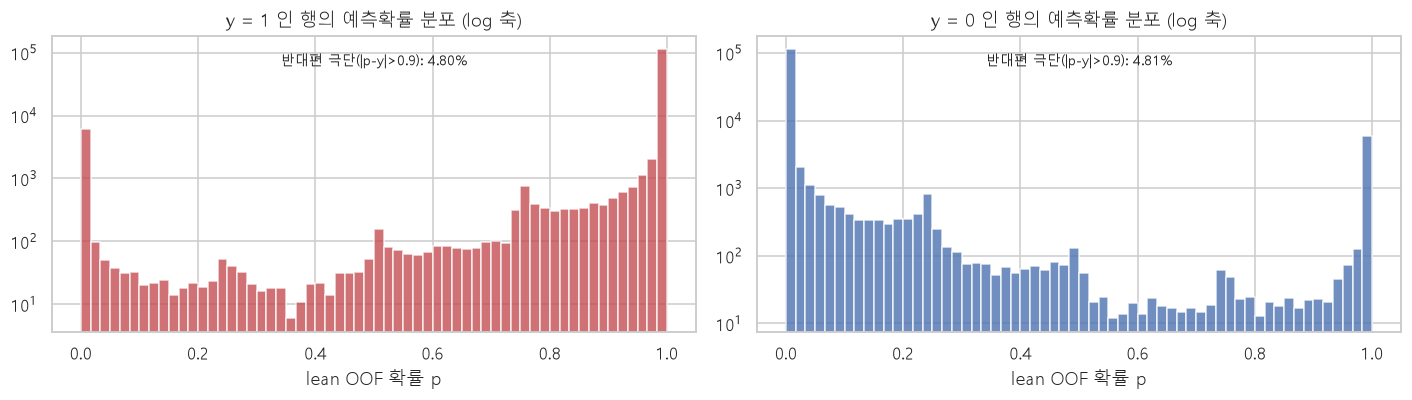

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
bins = np.linspace(0, 1, 61)
for ax, cls, color in ((axes[0], 1, "#c44e52"), (axes[1], 0, "#4c72b0")):
    ax.hist(p[y == cls], bins=bins, color=color, alpha=0.8)
    ax.set_yscale("log")
    ax.set_title(f"y = {cls} 인 행의 예측확률 분포 (log 축)")
    ax.set_xlabel("lean OOF 확률 p")
    wrong_side = (p[y == cls] < 0.1).mean() if cls == 1 else (p[y == cls] > 0.9).mean()
    ax.annotate(f"반대편 극단(|p-y|>0.9): {wrong_side:.2%}", xy=(0.5, 0.9), xycoords="axes fraction", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

> **관찰.** 두 클래스 모두 **반대편 극단에 4.8% 짜리 덩어리**가 있다. 경계 근처가 아니라 끝에 뭉쳐 있다.
> 모델이 "이건 확실히 0" 이라고 하는데 라벨은 1 인 행이 12,600개다.
> 이것만으로 단정할 수는 없다 — 모델이 확신 있게 틀리는 어려운 영역이 있을 수도 있다. 다음 세 절에서 구분한다.

## 2. 진단 A — 임계값에 둔감한가

**무엇을 하나** — "확신 오답"(p>τ 인데 y=0, p<1−τ 인데 y=1)의 비율을 τ 를 0.99 에서 0.6 까지 완화하며 잰다.

**원리** — 뒤집힌 라벨은 **어차피 극단에 있으므로** τ 를 완화해도 새로 잡히는 게 거의 없다 → 비율이 평평하다.
반면 진짜 모델 오류는 경계에서 극단까지 연속적으로 분포하므로 τ 를 완화할수록 **계속 늘어난다.**

**기대 결과** — 뒤집힘이면 평평, 모델 오류면 증가.

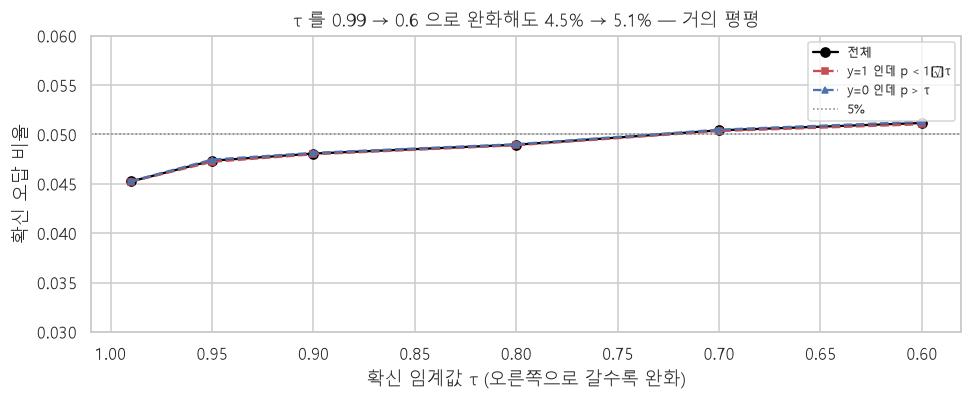

   τ  확신 오답 비율  y=1 & p<1−τ  y=0 & p>τ
0.99    0.0452       0.0452     0.0453
0.95    0.0473       0.0472     0.0475
0.90    0.0481       0.0480     0.0481
0.80    0.0490       0.0489     0.0490
0.70    0.0504       0.0503     0.0505
0.60    0.0512       0.0510     0.0513


In [3]:
cw = diag["real"]["conf_wrong"]
taus = sorted((float(t) for t in cw), reverse=True)
rates = [cw[str(t)]["rate"] for t in taus]
y1 = [cw[str(t)]["y1_pred_low"] for t in taus]; y0 = [cw[str(t)]["y0_pred_high"] for t in taus]

plt.figure(figsize=(9, 3.8))
plt.plot(taus, rates, "o-", color="black", label="전체")
plt.plot(taus, y1, "s--", color="#c44e52", ms=4, label="y=1 인데 p < 1−τ")
plt.plot(taus, y0, "^--", color="#4c72b0", ms=4, label="y=0 인데 p > τ")
plt.axhline(0.05, color="gray", ls=":", lw=1, label="5%")
plt.gca().invert_xaxis()
plt.ylim(0.03, 0.06)
plt.xlabel("확신 임계값 τ (오른쪽으로 갈수록 완화)")
plt.ylabel("확신 오답 비율")
plt.title("τ 를 0.99 → 0.6 으로 완화해도 4.5% → 5.1% — 거의 평평")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(pd.DataFrame({"τ": taus, "확신 오답 비율": rates, "y=1 & p<1−τ": y1, "y=0 & p>τ": y0}).round(4).to_string(index=False))

> **관찰.** τ=0.99 에서 4.52%, τ=0.6 에서 5.12% — 임계값을 이렇게 크게 완화했는데 0.6%p 밖에 안 늘었다.
> 그리고 두 클래스가 **소수점 셋째 자리까지 대칭**(0.0452 vs 0.0453)이다. 무작위로 뒤집었다면 당연히 대칭이어야 한다.
> 모델 오류가 우연히 이렇게 대칭일 이유는 없다.

## 3. 진단 B — 뒤집힘 비율을 추정하기

**무엇을 하나** — 혼합비 추정으로 f (뒤집힌 비율)를 숫자로 뽑는다.

**원리** — 라벨이 확률 f 로 무작위로 뒤집혔다면, **y=1 이라고 표시된 행**은 사실

$$ (1-f)\cdot[\text{진짜 양성}] + f\cdot[\text{진짜 음성}] $$

의 혼합이다. 진짜 양성은 p 가 아주 작은 곳(p < t, t=0.05 정도)에 거의 없으므로,
y=1 행 중 p<t 인 비율 a 는 거의 전부 "뒤집힌 진짜 음성"에서 온다. 같은 t 에서 y=0 행 중 p<t 인 비율을 b 라 하면

$$ a \approx f\cdot F_0(t), \qquad b \approx (1-f)\cdot F_0(t) \quad\Rightarrow\quad \hat f = \frac{a}{a+b} $$

**검증 방법** — 이 추정이 맞다면 ① t 를 바꿔도 같은 값이 나와야 하고 ② p>1−t 쪽(반대 꼬리)에서 추정해도 같아야 한다.
둘 다 일치하면 "우연히 맞은 숫자"가 아니다.

In [4]:
fe = diag["real"]["flip_estimates"]
tab = pd.DataFrame({t: {"낮은 꼬리 (p<t)": v["f_from_low_tail"], "높은 꼬리 (p>1−t)": v["f_from_high_tail"]} for t, v in fe.items()}).T
tab.index.name = "t"
display(tab.round(4))
est = float(np.mean(tab.to_numpy()))
print(f"추정 f = {est:.4f}   (t 5개 × 양쪽 꼬리 10개 값의 범위: {tab.to_numpy().min():.4f} ~ {tab.to_numpy().max():.4f})")

,낮은 꼬리 (p<t),높은 꼬리 (p>1−t)
t,,
0.01,0.0501,0.0501
0.02,0.0503,0.0501
0.05,0.0502,0.0504
0.1,0.0502,0.0503
0.2,0.0502,0.0503


추정 f = 0.0502   (t 5개 × 양쪽 꼬리 10개 값의 범위: 0.0501 ~ 0.0504)


> **관찰.** 10개의 독립적인 추정치가 **0.0501 ~ 0.0504** 에 모인다. t 를 20배 바꿔도(0.01 → 0.2), 꼬리를 바꿔도 같다.
> **라벨의 5.0% 가 뒤집혀 있다.** 스터디원의 "대략 5%" 추정이 정확했다.
>
> 참고로 sklearn 의 `flip_y` 는 "확률 flip_y 로 라벨을 **무작위 재배정**"이라 실제로 바뀌는 건 절반이다.
> 유효 뒤집힘 5% 는 `flip_y=0.10` 에 해당한다. (원 대회는 `flip_y=0.05` → 유효 2.5% 로 추정됐고, 그래서 천장이 0.975 였다.)

## 4. 진단 C — 그룹 사이에 균일한가, 그리고 02 노트북의 수수께끼

**무엇을 하나** — 그룹별 확신 오답 비율의 흩어짐을 **이항분포가 예측하는 흩어짐**과 비교하고, 그룹 AUC 와의 관계를 본다.

**원리** — 512행 중 5% 가 무작위로 뒤집힌다면 그룹별 뒤집힘 개수는 이항분포 B(512, 0.05) 를 따르고,
비율의 표준편차는 √(0.05·0.95/512) ≈ 0.0096 이다. 관측된 표준편차가 이와 같으면 "그룹 간 균일한 무작위",
훨씬 크면 "특정 그룹에 몰림"(= 모델이 어려워하는 그룹).

**그리고 02 노트북과의 연결** — [02](02_magic_group_structure.ipynb) 3절에서 그룹별 AUC 의 흩어짐 중
**83% 가 측정 오차**라고 결론지었다. 그 "측정 오차"의 정체가 여기서 드러난다.

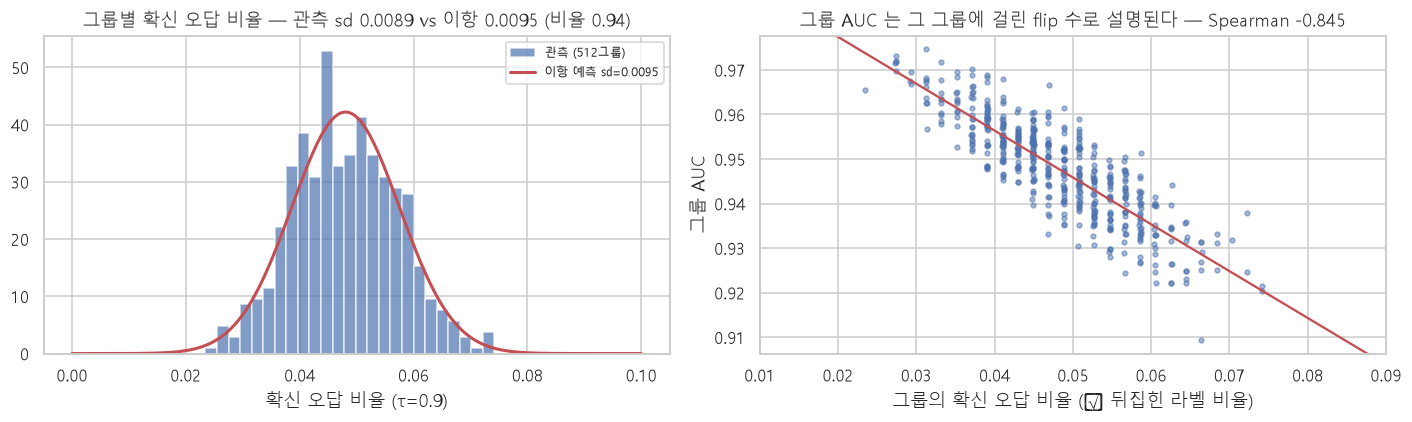

기울기: flip 비율 1%p 당 그룹 AUC -0.0105  (이론값: 완벽한 분류기면 flip 1%p 당 약 −0.01)


In [5]:
m09 = ((p > 0.9) & (y == 0)) | ((p < 0.1) & (y == 1))
g_rate = np.array([m09[s].mean() for s in slices])
g_auc = np.array([roc_auc_score(y[s], p[s]) for s in slices])
u = diag["real"]["uniformity"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(g_rate, bins=25, density=True, color="#4c72b0", alpha=0.7, label="관측 (512그룹)")
xs = np.linspace(0, 0.1, 300)
axes[0].plot(xs, stats.norm.pdf(xs, u["mean_rate"], u["binomial_sd"]), "r-", lw=2, label=f"이항 예측 sd={u['binomial_sd']:.4f}")
axes[0].set_title(f"그룹별 확신 오답 비율 — 관측 sd {u['observed_sd']:.4f} vs 이항 {u['binomial_sd']:.4f} (비율 {u['sd_ratio']:.2f})")
axes[0].set_xlabel("확신 오답 비율 (τ=0.9)")
axes[0].legend(fontsize=8)

axes[1].scatter(g_rate, g_auc, s=10, alpha=0.5)
fit = np.polyfit(g_rate, g_auc, 1)
axes[1].plot(xs, np.polyval(fit, xs), "r-", lw=1.5)
axes[1].set_xlim(0.01, 0.09); axes[1].set_ylim(g_auc.min() - 0.003, g_auc.max() + 0.003)
axes[1].set_xlabel("그룹의 확신 오답 비율 (≈ 뒤집힌 라벨 비율)")
axes[1].set_ylabel("그룹 AUC")
axes[1].set_title(f"그룹 AUC 는 그 그룹에 걸린 flip 수로 설명된다 — Spearman {u['spearman_vs_group_auc']:+.3f}")
plt.tight_layout()
plt.show()

print(f"기울기: flip 비율 1%p 당 그룹 AUC {fit[0] * 0.01:+.4f}  (이론값: 완벽한 분류기면 flip 1%p 당 약 −0.01)")

> **관찰.** 관측 sd / 이항 sd = **0.94** — 그룹별 뒤집힘 개수는 정확히 무작위 이항분포다. 특정 그룹에 몰리지 않는다.
>
> 그리고 **그룹 AUC 와 Spearman −0.845.** 02 노트북에서 "진짜 그룹 난이도 차이는 17%뿐, 나머지는 측정 오차"라고 했는데,
> 그 측정 오차의 실체는 **그 그룹에 우연히 몇 개의 라벨이 뒤집혔느냐**였다.
> 뒤집힌 라벨이 1%p 많은 그룹은 AUC 가 약 0.01 낮다 — 완벽한 분류기라도 그렇게 된다.
>
> 이것으로 [04](04_model_diagnostics.ipynb) 4절의 "그룹별 모델 선택은 잡음 추종" 결론에도 원인이 붙는다.
> 어려운 그룹이 있는 게 아니라, **운 나쁘게 flip 이 많이 걸린 그룹**이 있는 것이다. 어떤 모델을 골라도 그 flip 은 맞힐 수 없다.

## 5. 천장 계산 — 라벨의 f 가 뒤집혀 있으면 AUC 는 최대 얼마인가

**무엇을 하나** — 진짜 클래스를 완벽히 아는 분류기가 **뒤집힌 라벨로 채점**될 때의 AUC 를 계산한다.

**원리** — AUC = "양성으로 표시된 행 하나와 음성으로 표시된 행 하나를 뽑았을 때, 양성 쪽 점수가 더 높을 확률".
완벽한 분류기는 진짜 양성에 1, 진짜 음성에 0 을 준다. 표시된 라벨은 확률 f 로 틀렸다.

| 뽑힌 쌍 (표시 양성, 표시 음성) | 확률 | 점수 비교 |
|---|---|---|
| (진짜 양성, 진짜 음성) | (1−f)² | 1 > 0 → 맞음 |
| (진짜 양성, 뒤집힌 진짜 양성) | (1−f)·f | 1 = 1 → 동점 (½) |
| (뒤집힌 진짜 음성, 진짜 음성) | f·(1−f) | 0 = 0 → 동점 (½) |
| (뒤집힌 진짜 음성, 뒤집힌 진짜 양성) | f² | 0 < 1 → 틀림 |

$$ \mathrm{AUC}_{\max} = (1-f)^2 + 2f(1-f)\cdot\tfrac12 = (1-f)^2 + f(1-f) = 1 - f $$

**f = 0.05 이면 천장은 0.95.** 완벽한 분류기도 0.95 를 넘지 못한다.
(점수가 연속값이면 동점이 깨져 조금 달라질 수 있지만, 진짜 클래스 안에서의 순서는 flip 과 무관하므로 기대값은 그대로다.)

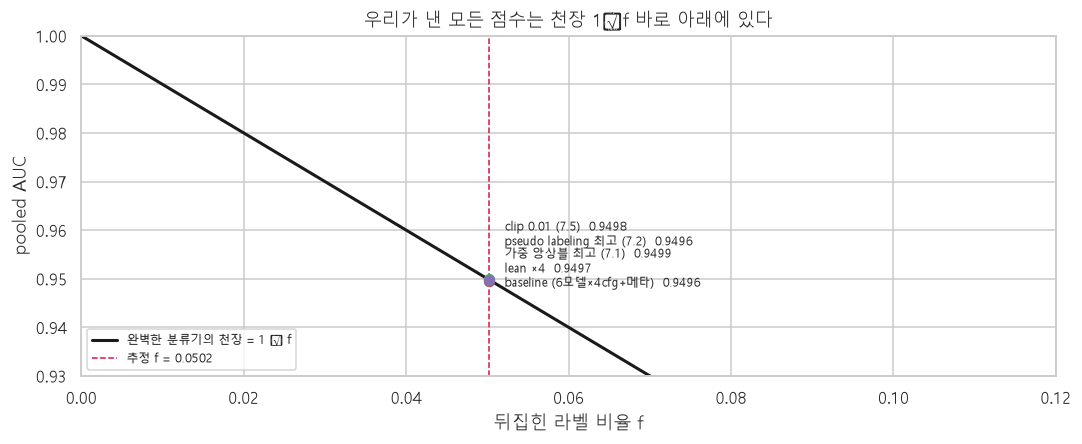

천장 (f=0.0502) = 0.9498
  baseline (6모델×4cfg+메타)       0.949605  천장까지 +0.000170
  lean ×4                      0.949699  천장까지 +0.000076
  가중 앙상블 최고 (7.1)              0.949943  천장까지 -0.000168
  pseudo labeling 최고 (7.2)     0.949614  천장까지 +0.000161
  clip 0.01 (7.5)              0.949832  천장까지 -0.000057


In [6]:
fs = np.linspace(0, 0.12, 200)
ceiling = 1 - fs
obs = {
    "baseline (6모델×4cfg+메타)": base_m["final_auc"],
    "lean ×4": lean_m["final_auc"],
    "가중 앙상블 최고 (7.1)": 0.949943,
    "pseudo labeling 최고 (7.2)": 0.949614,
    "clip 0.01 (7.5)": cal["results"]["clip_0.01"]["pooled_auc"],
}
plt.figure(figsize=(10, 4.2))
plt.plot(fs, ceiling, "k-", lw=2, label="완벽한 분류기의 천장 = 1 − f")
plt.axvline(est, color="crimson", ls="--", lw=1, label=f"추정 f = {est:.4f}")
for i, (k, v) in enumerate(obs.items()):
    plt.scatter([est], [v], s=40, zorder=3)
    plt.annotate(f"{k}  {v:.4f}", (est, v), xytext=(10, -4 + 9 * i), textcoords="offset points", fontsize=8)
plt.ylim(0.93, 1.0); plt.xlim(0, 0.12)
plt.xlabel("뒤집힌 라벨 비율 f")
plt.ylabel("pooled AUC")
plt.title("우리가 낸 모든 점수는 천장 1−f 바로 아래에 있다")
plt.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

print(f"천장 (f={est:.4f}) = {1 - est:.4f}")
for k, v in obs.items():
    print(f"  {k:28s} {v:.6f}  천장까지 {1 - est - v:+.6f}")

> **관찰.** baseline, lean, 가중 앙상블, pseudo labeling — **전부 천장 0.950 에서 0.0003~0.0004 아래**에 있다.
> 6개 모델을 스태킹해도, 21가지 가중치를 시험해도, 가짜 라벨을 붙여도 0.9500 을 못 넘은 이유는
> 방법이 나빠서가 아니라 **채점 라벨의 5% 가 틀려 있어서 맞힐 방법이 없기 때문**이다.
>
> > **이 노트북의 가장 중요한 교훈** — 최적화를 시작하기 전에 **지표의 천장이 어디인지** 먼저 알아야 한다.
> > 우리는 다섯 개의 실험(수 시간의 계산)을 천장에서 0.0004 떨어진 지점에서 했다.
> > 진단 A~C 는 40초짜리 스크립트다.

## 6. 합성 대조 — 진짜 라벨을 아는 세계

**무엇을 하나** — 실제 그룹과 같은 구조(`make_classification`, informative 33~47개, 클래스당 3군집)의 가짜 그룹을 만들어
뒤집힘 비율을 0 / 0.02 / 0.05 / 0.08 로 바꾸며 lean 을 돌린다. 합성이니 **진짜 라벨로도 채점**할 수 있다.

**왜 하나** — 실제 데이터에서는 "모델이 나쁜가, 라벨이 나쁜가"를 분리할 수 없다. 합성에서는 된다.
그리고 어떤 f 가 실제 AUC(0.9497)를 재현하는지 보면 f 추정의 독립적 검증이 된다.

,AUC (뒤집힌 라벨로 채점),AUC (진짜 라벨로 채점),확신 오답 비율(τ=0.9),추정 f (B 방법),탐지기 정밀도,탐지기 재현율
flip,,,,,,
0.00,0.9993,0.9993,0.0052,0.0039,0.0000,NaN
0.02,0.9796,0.9992,0.0248,0.0242,0.7638,0.9724
0.05,0.9498,0.9995,0.0534,0.0511,0.9196,0.9786
0.08,0.9211,0.9988,0.0817,0.0844,0.9277,0.9670


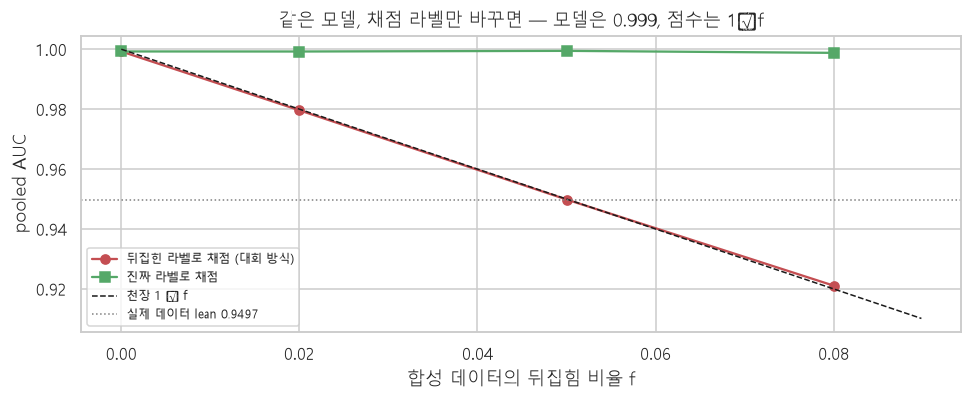

In [7]:
rows = []
for f_str, s in diag["synthetic"].items():
    rows.append({"flip": float(f_str), "AUC (뒤집힌 라벨로 채점)": s["pooled_auc_vs_noisy_labels"], "AUC (진짜 라벨로 채점)": s["pooled_auc_vs_true_labels"],
                 "확신 오답 비율(τ=0.9)": s["conf_wrong_rate"]["0.9"], "추정 f (B 방법)": s["flip_estimates"]["0.05"]["f_from_low_tail"],
                 "탐지기 정밀도": s["detector"]["0.9"]["precision"], "탐지기 재현율": s["detector"]["0.9"]["recall"]})
syn = pd.DataFrame(rows).set_index("flip")
display(syn.round(4))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(syn.index, syn["AUC (뒤집힌 라벨로 채점)"], "o-", color="#c44e52", label="뒤집힌 라벨로 채점 (대회 방식)")
ax.plot(syn.index, syn["AUC (진짜 라벨로 채점)"], "s-", color="#55a868", label="진짜 라벨로 채점")
ax.plot(fs[fs <= 0.09], 1 - fs[fs <= 0.09], "k--", lw=1, label="천장 1 − f")
ax.axhline(lean_m["final_auc"], color="gray", ls=":", lw=1, label=f"실제 데이터 lean {lean_m['final_auc']:.4f}")
ax.set_xlabel("합성 데이터의 뒤집힘 비율 f"); ax.set_ylabel("pooled AUC")
ax.set_title("같은 모델, 채점 라벨만 바꾸면 — 모델은 0.999, 점수는 1−f")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

> **관찰.**
> - **f=0.05 인 합성 데이터에서 lean 의 점수는 0.9498** — 실제 데이터의 0.9497 과 소수점 셋째 자리까지 같다.
>   f 추정(B)이 독립적으로 재확인됐다.
> - 같은 예측을 **진짜 라벨로 채점하면 0.9995.** 모델은 거의 완벽하다. 0.95 와 1.0 사이의 격차는 전부 라벨 노이즈다.
> - 추정기 B 는 합성에서도 f 를 정확히 맞힌다(0.02 → 0.024, 0.05 → 0.051, 0.08 → 0.084).
> - 확신 오답 탐지기(τ=0.9)의 정밀도 0.92, 재현율 0.98 — **뒤집힌 라벨의 98% 를 잡고, 잡은 것의 92% 가 진짜 뒤집힘**이다.
>   즉 학습에서 노이즈를 빼는 것은 기술적으로 가능하다. 문제는 그게 점수에 보이느냐다 → 다음 절.

## 7. 노이즈 제거 학습 — 되는가, 그리고 단순한 모델이 따라잡는가

**무엇을 하나** — lean 의 fold 안에 "내부 CV 로 노이즈를 표시해 제거 → 재적합" 단계를 끼워 512그룹 전체에서 잰다.
동시에 합성 그룹에서 같은 절차를 돌려 **진짜 라벨 기준**의 효과도 본다.

### ⚠️ 누수 없는 프로토콜 (여기가 제일 틀리기 쉽다)

```
outer fold (학습 T, 검증 V) 마다:
  1. T 안에서만 내부 5-fold → T 각 행의 내부 OOF 확률        ← V 라벨은 전혀 보지 않음
  2. 내부 OOF 가 라벨과 확신 있게 어긋나는 T 의 행을 제거(또는 뒤집기)
  3. 정리된 T 로 QDA 재적합 → V 예측
```

"어느 행이 노이즈인가"를 판단하는 모델이 V 의 라벨을 봤다면, 그 정보가 제거 결정을 통해 새어 들어간다.
대조군(제거 없음)이 lean 을 **비트 단위로 재현**하는지도 확인한다.

**기대 (5절을 알고 있다면)** — 채점 라벨의 5% 가 뒤집혀 있으므로 **점수는 0.0003 이상 오를 수 없다.**
합성의 진짜 라벨 기준으로는 오를 수 있다 — 그게 얼마인지가 "모델이 노이즈에 얼마나 상했는가"의 답이다.

대조군 재현 검사: |control − lean| = 0.00e+00


,pooled AUC,Δ pooled,Δ 그룹별 (95% CI),이긴 그룹,제거/뒤집은 비율
설정,,,,,
control,0.949699,0.000000,"+0.00000 [+0.00000, +0.00000]",0/512,0.000000
drop_0.8,0.949797,0.000099,"+0.00146 [+0.00116, +0.00176]",353/512,0.057849
drop_0.9,0.949822,0.000123,"+0.00148 [+0.00118, +0.00177]",354/512,0.055525
drop_0.95,0.949819,0.000120,"+0.00145 [+0.00115, +0.00174]",357/512,0.053757
drop_0.99,0.949825,0.000127,"+0.00140 [+0.00111, +0.00169]",354/512,0.050740
flip_0.9,0.949852,0.000153,"+0.00146 [+0.00115, +0.00178]",342/512,0.055525
flip_0.95,0.949845,0.000147,"+0.00147 [+0.00116, +0.00178]",341/512,0.053757
drop_0.9_r2,0.949822,0.000124,"+0.00154 [+0.00124, +0.00183]",349/512,0.058997
drop_0.9_reg0.05,0.949851,0.000152,"+0.00145 [+0.00114, +0.00176]",352/512,0.056661


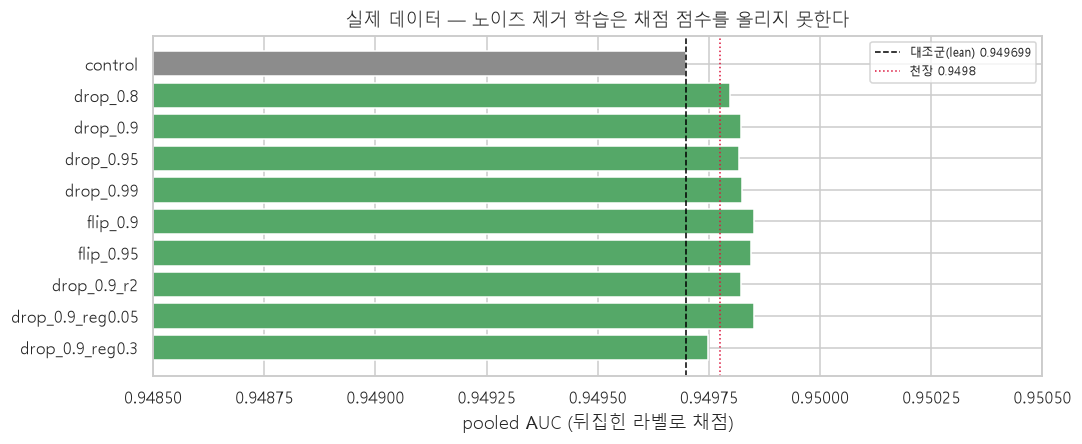

In [8]:
res = den["results"]
ctrl = res["control"]["pooled_auc"]
rows = []
for name, r in res.items():
    v = r["vs_control"]
    rows.append({"설정": name, "pooled AUC": r["pooled_auc"], "Δ pooled": r["pooled_auc"] - ctrl,
                 "Δ 그룹별 (95% CI)": f"{v['mean']:+.5f} [{v['ci_low']:+.5f}, {v['ci_high']:+.5f}]",
                 "이긴 그룹": f"{v['wins']}/{v['n']}", "제거/뒤집은 비율": r["removed_frac_mean"]})
dtab = pd.DataFrame(rows).set_index("설정")
chk = den.get("reproduction_check")
print(f"대조군 재현 검사: |control − lean| = {chk['abs_diff']:.2e}" if chk else "재현 검사 없음 (magic-limit 축소 실행)")
display(dtab.round(6))

plt.figure(figsize=(10, 4.2))
names = [n for n in dtab.index if not n.startswith("raw")]
cols = ["#8c8c8c" if n == "control" else ("#55a868" if dtab.loc[n, "pooled AUC"] > ctrl else "#c44e52") for n in names]
plt.barh(names, dtab.loc[names, "pooled AUC"], color=cols)
plt.axvline(ctrl, color="black", ls="--", lw=1, label=f"대조군(lean) {ctrl:.6f}")
plt.axvline(1 - est, color="crimson", ls=":", lw=1, label=f"천장 {1 - est:.4f}")
plt.xlim(0.9485, 0.9505)
plt.xlabel("pooled AUC (뒤집힌 라벨로 채점)")
plt.title("실제 데이터 — 노이즈 제거 학습은 채점 점수를 올리지 못한다")
plt.legend(fontsize=8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,AUC (뒤집힌 라벨),AUC (진짜 라벨),제거 비율,제거 정밀도
설정,,,,
lean_control,0.9491,0.9992,0.0000,NaN
raw_control,0.9379,0.9861,0.0000,NaN
raw_reg0.5,0.9342,0.9820,0.0000,NaN
lean_drop_0.9,0.9493,0.9992,0.0553,0.8825
raw_drop_0.9,0.9396,0.9878,0.0696,0.6054
lean_flip_0.9,0.9492,0.9991,0.0553,0.8825
lean_drop_0.99,0.9493,0.9992,0.0508,0.9330
raw_drop_0.99,0.9402,0.9884,0.0451,0.7916
lean_flip_0.99,0.9492,0.9992,0.0508,0.9330


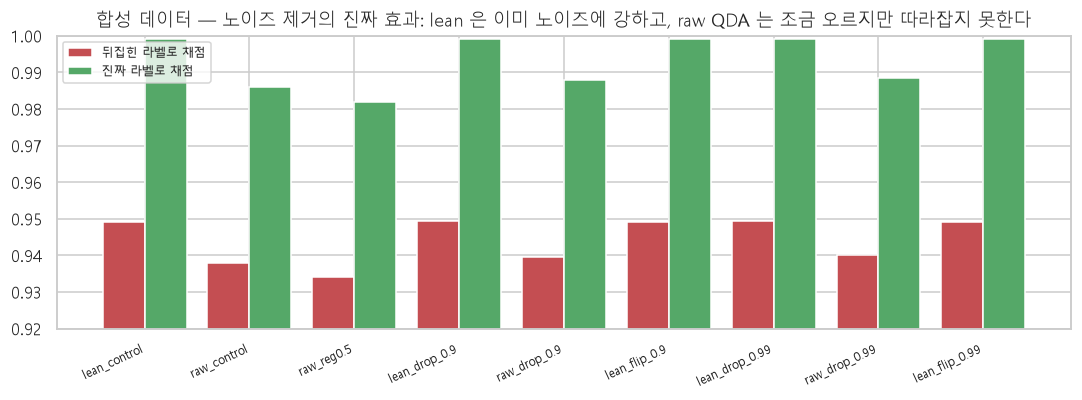

In [9]:
sr = synth_dn["results"]
srows = [{"설정": n, "AUC (뒤집힌 라벨)": r["auc_noisy_labels"], "AUC (진짜 라벨)": r["auc_true_labels"],
          "제거 비율": r["removed_frac"], "제거 정밀도": r["removed_precision"]} for n, r in sr.items()]
stab = pd.DataFrame(srows).set_index("설정")
display(stab.round(4))

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(stab))
ax.bar(x - 0.2, stab["AUC (뒤집힌 라벨)"], 0.4, label="뒤집힌 라벨로 채점", color="#c44e52")
ax.bar(x + 0.2, stab["AUC (진짜 라벨)"], 0.4, label="진짜 라벨로 채점", color="#55a868")
ax.set_xticks(x); ax.set_xticklabels(stab.index, rotation=25, ha="right", fontsize=8)
ax.set_ylim(0.92, 1.0)
ax.set_title("합성 데이터 — 노이즈 제거의 진짜 효과: lean 은 이미 노이즈에 강하고, raw QDA 는 조금 오르지만 따라잡지 못한다")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

> **관찰 — 실제 데이터.** 대조군은 lean 을 비트 단위로 재현했다(|diff| = 0).
> 노이즈 제거는 **그룹별 AUC 를 +0.0015 유의하게 올린다** (drop τ=0.9: [+0.0012, +0.0018], 354/512 그룹 승,
> 그룹 평균 0.9479 → 0.9494 — 천장 0.95 까지 0.0006). 그룹 안 순위는 실제로 좋아진다.
> 하지만 **pooled 는 +0.00012 ~ +0.00015** — 잡음 기준(0.0001)과 같은 크기이고, 천장까지 남아 있던 0.0003 의 절반이다.
> **대회 점수로는 보이지 않는다.**
> 제거된 비율은 5.1~5.6% 로 추정 f 와 정확히 맞는다 — 탐지기가 노이즈만큼만 뺀다.
> drop 과 flip, 1회와 2회 반복, reg 0.111 과 0.05 는 서로 구분되지 않는다.
>
> **관찰 — 합성 데이터(진짜 라벨 기준).**
> - `lean`: 노이즈 제거 전후 진짜 라벨 AUC **0.9992 → 0.9992.** 변화 없음. **lean 은 이미 5% 라벨 노이즈에 강하다.**
>   (GMM 은 라벨을 쓰지 않으니 노이즈와 무관하고, QDA 의 `reg_param` 이 오염된 공분산을 이미 덮고 있었다.)
> - `raw QDA` (GMM 피처 없음): 0.9861 → 0.9884 (+0.0023). 노이즈 제거가 도움이 되지만 **lean 의 0.9992 에는 한참 못 미친다.**
>
> ### 스터디원 가설의 판정
> - "노이즈가 5% 있다" → ✅ 정확히 맞았다 (f = 0.050)
> - "빼고 학습하면 더 좋아진다" → ❌ 점수로는 불가능하다 — 채점 라벨이 뒤집혀 있어 천장이 0.95 다.
>   진짜 성능 기준으로도 lean 은 이미 0.9992 라 오를 여지가 없다
> - "더 단순한 모델이 따라잡는다" → ❌ raw QDA 가 뒤처지는 원인은 라벨 노이즈가 아니라 **GMM 피처(transductive)의 부재**다.
>   노이즈를 빼도 0.9884 에 머문다
>
> 가설의 절반이 틀렸지만, **이 가설을 검증하는 과정에서 "왜 모든 방법이 0.95 에서 멈추는가"의 답이 나왔다.**
> 이것이 나머지 실험 전부를 합친 것보다 값진 결과다.

## 8. 캘리브레이션의 착시 — 라벨 노이즈에 과적합한 이득

**무엇을 하나** — 7.5절의 그룹 간 캘리브레이션 결과를 노이즈 관점에서 다시 읽는다.

**왜 여기서 다루나** — 캘리브레이션 실험에는 **in-sample 로 맞추면 +0.0022, 교차 적합하면 −0.0006** 이라는
부호가 뒤집히는 결과가 있다. 라벨 노이즈를 알면 이게 왜 그런지 정확히 설명된다.

,pooled AUC,Δ vs lean,95% CI,그룹별 AUC 평균
방법,,,,
temperature,0.949062,-0.000637,"[-0.00102, -0.00029]",0.946963
platt,0.948756,-0.000943,"[-0.00128, -0.00061]",0.946114
bias,0.948791,-0.000908,"[-0.00130, -0.00044]",0.947221
rank,0.948404,-0.001295,"[-0.00163, -0.00100]",0.948934
zscore,0.948853,-0.000846,"[-0.00114, -0.00054]",0.948934
temperature_insample_upper_bound,0.951252,0.001553,—,0.948934
platt_insample_upper_bound,0.951933,0.002234,—,0.948934
clip_0.01,0.949832,0.000133,—,0.949780


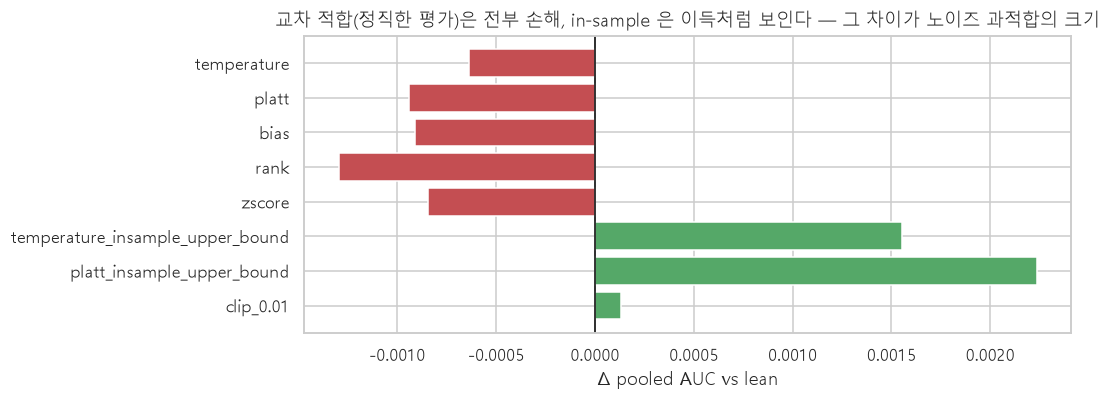

In [10]:
cr = cal["results"]
pick = ["temperature", "platt", "bias", "rank", "zscore", "temperature_insample_upper_bound", "platt_insample_upper_bound", "clip_0.01"]
ctab = pd.DataFrame([{"방법": k, "pooled AUC": cr[k]["pooled_auc"], "Δ vs lean": cr[k]["delta_vs_raw"],
                      "95% CI": f"[{cr[k]['boot_ci_low']:+.5f}, {cr[k]['boot_ci_high']:+.5f}]" if "boot_ci_low" in cr[k] else "—",
                      "그룹별 AUC 평균": cr[k]["group_auc_mean"]} for k in pick]).set_index("방법")
display(ctab.round(6))

plt.figure(figsize=(10, 3.8))
vals = ctab["Δ vs lean"]
cols = ["#55a868" if v > 0 else "#c44e52" for v in vals]
plt.barh(ctab.index, vals, color=cols)
plt.axvline(0, color="black", lw=1)
plt.xlabel("Δ pooled AUC vs lean")
plt.title("교차 적합(정직한 평가)은 전부 손해, in-sample 은 이득처럼 보인다 — 그 차이가 노이즈 과적합의 크기")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

> **관찰.**
> - 교차 적합한 보정(temperature/platt/bias)은 **전부 pooled 를 낮춘다** (−0.0006 ~ −0.0009, CI 가 0 을 제외).
> - 같은 보정기를 **같은 행으로 맞춰 같은 행에 적용**하면 +0.0016 ~ +0.0022 로 보인다.
>
> ### 왜 in-sample 은 좋아 보이나
> 그룹의 라벨 5% 가 무작위로 뒤집혀 있다. 보정기의 절편 b 는 그 그룹에서 "높은 p 인데 y=0" 인 행이 몇 개인지에 반응한다 —
> 즉 **그 그룹에 실현된 flip 개수에 맞춰진다.** 그렇게 맞춘 보정기를 같은 행에 적용하면 뒤집힌 행들의 점수가 조정되어
> pooled 가 오른 것처럼 보이지만, 그 flip 은 **다른 행에서는 재현되지 않는 잡음**이라 교차 적합에서 부호가 뒤집힌다.
>
> > **초보자에게** — "보정기를 학습 데이터에 맞춰 학습 데이터에서 평가"하면 거의 항상 좋아 보인다.
> > 04 노트북 5절(가중 앙상블)에서 본 것과 같은 함정이고, 라벨 노이즈가 있으면 그 착시가 더 커진다.
>
> **클리핑(p 를 [0.01, 0.99] 로)** 은 라벨을 안 쓰는데도 +0.00013 — 잡음 수준이지만 방향이 노이즈 가설과 맞는다.
> 뒤집힌 라벨의 행은 다른 클래스 군집 한가운데 있어 **가장 극단적인 확률**을 받으므로, 극단값들의 순서를 동점으로 없애면
> 그들 사이의 "틀린 순서"가 사라진다. 그룹별 AUC 가 +0.0019 나 오르는 게 그 흔적이다.

## 9. flip 으로 다시 — 정정된 라벨 위에서 ablation 재실행

7절의 방법에 대해 스터디원이 세 가지를 지적했다.

1. 노이즈 행은 **버리지(drop) 말고 뒤집어야(flip)** 한다 — 뒤집힌 행은 다른 클래스의 완벽한 샘플이라 버리면 그룹당 ~25행을 잃는다
2. 정정한 뒤 **라벨을 쓰는 단계를 전부 다시** 돌려야 한다 — 탐지기도 정정된 라벨로 다시 학습해 반복
3. **ablation 도 정정된 라벨 위에서 다시** 해야 한다 — 노이즈 5% 가 있을 때 잰 부품 중요도와 깨끗한 라벨에서의 중요도는 다를 수 있다.
   **baseline 의 복잡성이 사실은 노이즈 보상 장치였을 가능성**

셋 다 방법론으로 옳다. 그래서 실험을 다시 설계했다 (`experiments/relabel/relabel.py`).

**설계에서 알아둘 것** — lean 의 피처(std 선택·KernelPCA·GMM·scaler)는 라벨을 쓰지 않으므로 flip 으로 바뀌지 않는다.
라벨이 들어가는 곳은 (a) 분류기 적합 (b) 탐지기 (c) **라벨을 쓰는 피처 추출**(클래스별 GMM, LDA)이다.
(c) 는 노이즈 때문에 지금까지 불리하게 평가됐을 수 있어 후보에 넣었다.

**평가** — 검증 라벨도 뒤집혀 있어 실제 데이터의 차이는 천장에 눌린다. 그래서 진짜 라벨을 아는 합성 60그룹에서
**라벨 모드 {noisy, flip×1, ×2, ×3, oracle(진짜 라벨로 학습)} × 파이프라인 11개** 를 돌리고 진짜 라벨 기준으로 읽는다.
oracle 은 "라벨 정정을 완벽히 했다면"의 상한이다 — **가설을 가장 강한 형태로 시험하는 장치**다.

In [11]:
rel_s = load_json(EXP / "relabel" / "outputs" / "synth_metrics.json")
rel_r = load_json(EXP / "relabel" / "outputs" / "real_metrics.json")
modes_s = rel_s["config"]["label_modes"]; modes_r = rel_r["config"]["label_modes"]
pipes = rel_s["config"]["pipelines"]

true_tab = pd.DataFrame({m: {p: rel_s["results"][f"{m}::{p}"]["pooled_auc_true"] for p in pipes} for m in modes_s})
real_tab = pd.DataFrame({m: {p: rel_r["results"][f"{m}::{p}"]["pooled_auc_noisy"] for p in pipes} for m in modes_r})
print("합성 60그룹 — 진짜 라벨 기준 AUC (행: 파이프라인, 열: 학습 라벨 모드)")
display(true_tab.round(4))
print("실제 512그룹 · 시드 2개 — pooled AUC, 뒤집힌 라벨로 채점")
display(real_tab.round(6))

chk = rel_r.get("reproduction_check")
print(f"대조군(noisy, lean) 재현 검사 vs simplify lean_2seeds: |diff| = {chk['abs_diff']:.2e}" if chk else "")

합성 60그룹 — 진짜 라벨 기준 AUC (행: 파이프라인, 열: 학습 라벨 모드)


,noisy,flip_r1,flip_r2,flip_r3,oracle
lean|qda,0.9998,0.9998,0.9998,0.9998,0.9999
-kpca|qda,0.9999,0.9999,0.9999,0.9999,0.9999
-gmm|qda,0.9878,0.9911,0.9910,0.9909,0.9916
-scaler|qda,0.9998,0.9998,0.9997,0.9997,0.9998
-transductive|qda,0.9869,0.9898,0.9897,0.9895,0.9904
raw|qda,0.9881,0.9912,0.9912,0.9910,0.9917
raw|qda_reg0.5,0.9840,0.9867,0.9865,0.9864,0.9872
raw|lda,0.8233,0.8299,0.8297,0.8294,0.8307
raw|gmm_bayes_k1,0.9881,0.9913,0.9912,0.9911,0.9917
raw|gmm_bayes_k3,0.9874,0.9926,0.9931,0.9928,0.9936


실제 512그룹 · 시드 2개 — pooled AUC, 뒤집힌 라벨로 채점


,noisy,flip_r1,flip_r2,flip_r3
lean|qda,0.949684,0.949665,0.949615,0.949566
-kpca|qda,0.949385,0.949487,0.949496,0.949500
-gmm|qda,0.937960,0.941224,0.941103,0.940941
-scaler|qda,0.950080,0.949821,0.949732,0.949670
-transductive|qda,0.937132,0.940169,0.940021,0.939827
raw|qda,0.938327,0.941657,0.941518,0.941366
raw|qda_reg0.5,0.934803,0.937697,0.937519,0.937357
raw|lda,0.790381,0.796121,0.795799,0.795584
raw|gmm_bayes_k1,0.938296,0.941677,0.941540,0.941389
raw|gmm_bayes_k3,0.938426,0.943679,0.943567,0.943347


대조군(noisy, lean) 재현 검사 vs simplify lean_2seeds: |diff| = 0.00e+00


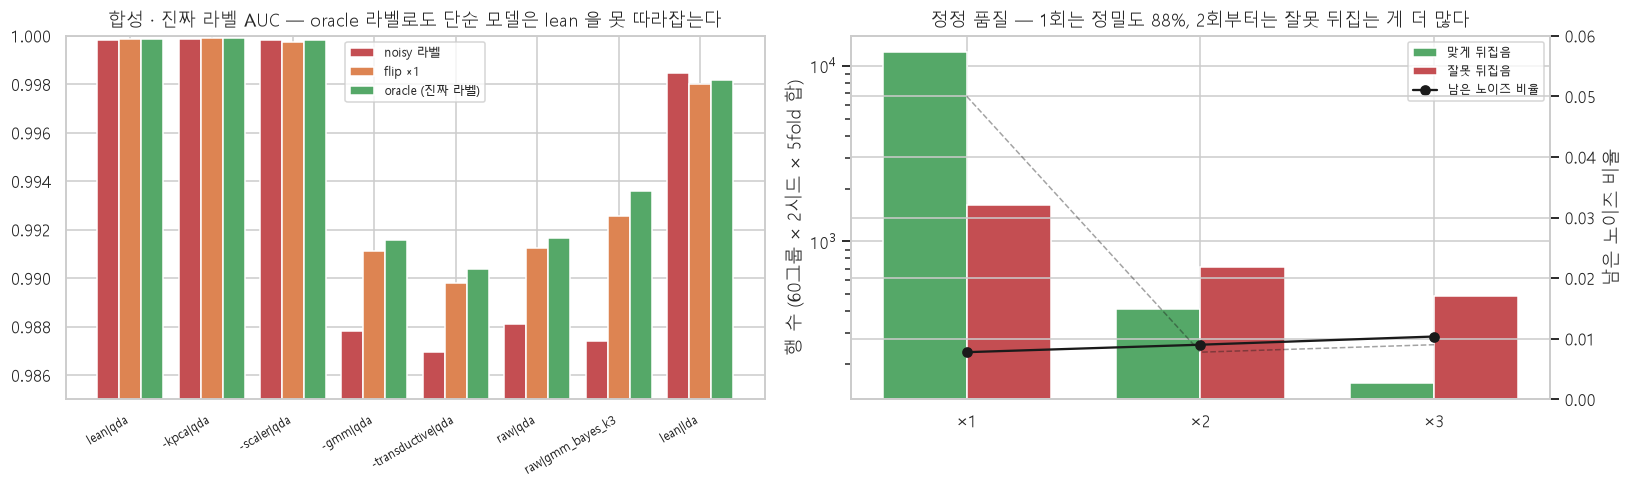

flip_r1: 뒤집은 비율 0.0551, 맞음 11,915 / 틀림 1,620 (정밀도 0.88), 남은 노이즈 0.0078
flip_r2: 뒤집은 비율 0.0046, 맞음 413 / 틀림 716 (정밀도 0.37), 남은 노이즈 0.0090
flip_r3: 뒤집은 비율 0.0026, 맞음 157 / 틀림 489 (정밀도 0.24), 남은 노이즈 0.0104


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
show = ["lean|qda", "-kpca|qda", "-scaler|qda", "-gmm|qda", "-transductive|qda", "raw|qda", "raw|gmm_bayes_k3", "lean|lda"]
x = np.arange(len(show))
w = 0.27
for i, (m, c) in enumerate((("noisy", "#c44e52"), ("flip_r1", "#dd8452"), ("oracle", "#55a868"))):
    axes[0].bar(x + (i - 1) * w, [true_tab.loc[p, m] for p in show], w, label={"noisy": "noisy 라벨", "flip_r1": "flip ×1", "oracle": "oracle (진짜 라벨)"}[m], color=c)
axes[0].set_xticks(x); axes[0].set_xticklabels(show, rotation=30, ha="right", fontsize=8)
axes[0].set_ylim(0.985, 1.0)
axes[0].set_title("합성 · 진짜 라벨 AUC — oracle 라벨로도 단순 모델은 lean 을 못 따라잡는다")
axes[0].legend(fontsize=8)

cs = rel_s["clean_stats"]
rounds = list(cs)
rem = [cs[r]["remaining_noise"] / cs[r]["rows"] for r in rounds]
corr = [cs[r]["correct"] for r in rounds]; wrong = [cs[r]["wrong"] for r in rounds]
ax2 = axes[1]
ax2.bar(np.arange(len(rounds)) - 0.18, corr, 0.36, color="#55a868", label="맞게 뒤집음")
ax2.bar(np.arange(len(rounds)) + 0.18, wrong, 0.36, color="#c44e52", label="잘못 뒤집음")
ax2.set_xticks(range(len(rounds))); ax2.set_xticklabels(["×1", "×2", "×3"])
ax2.set_ylabel("행 수 (60그룹 × 2시드 × 5fold 합)")
ax2.set_yscale("log")
ax3 = ax2.twinx()
ax3.plot(range(len(rounds)), [rel_s["config"]["flip"]] + rem[:-1], "k--", lw=1, alpha=0.4)
ax3.plot(range(len(rounds)), rem, "ko-", label="남은 노이즈 비율")
ax3.set_ylim(0, 0.06); ax3.set_ylabel("남은 노이즈 비율")
ax2.set_title("정정 품질 — 1회는 정밀도 88%, 2회부터는 잘못 뒤집는 게 더 많다")
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax3.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

for r in rounds:
    c = cs[r]
    print(f"{r}: 뒤집은 비율 {c['flipped'] / c['rows']:.4f}, 맞음 {c['correct']:,} / 틀림 {c['wrong']:,} "
          f"(정밀도 {c['correct'] / max(c['flipped'], 1):.2f}), 남은 노이즈 {c['remaining_noise'] / c['rows']:.4f}")

> **관찰 1 — flip 은 노이즈에 상한 모델만 살린다.** GMM 피처가 없는 단순 모델(raw QDA, −GMM, −transductive, 클래스별 GMM)은
> flip ×1 로 진짜 라벨 AUC 가 **+0.003~0.005** 오르고 oracle 의 75~85% 를 회수한다.
> lean 은 0.9998 → 0.9998, 변화 없음 — 이미 노이즈에 강하다.
>
> **관찰 2 — oracle 라벨로 학습해도 단순 모델은 lean 을 따라잡지 못한다.**
> 완벽한 라벨로 학습한 raw QDA 0.9917, 클래스별 GMM(k=3) 0.9936 vs lean 0.9999.
> **GMM 소속확률과 transductive 적합은 노이즈 보상 장치가 아니라 깨끗한 라벨에서도 필요한 부품**이다.
> "라벨을 정정하면 더 단순한 모델로 충분하다"는 가설은 가장 강한 형태(oracle)에서 기각됐다.
>
> **관찰 3 — ablation 순위는 라벨을 정정해도 바뀌지 않는다.** 결정적 부품(GMM proba, transductive)은 oracle 에서도 −0.008 로 결정적이고,
> KernelPCA 와 scaler 는 진짜 라벨 기준으로 그룹 안 성능에 무효다 (−KernelPCA 가 오히려 0.9999).
> KernelPCA 의 역할은 [05](05_ablation.ipynb) 9절 그대로 **그룹 간 스케일**이다(실제 pooled −0.0003).
>
> **관찰 4 — 반복은 1회가 최선.** ×1 은 정밀도 88% 로 노이즈를 5.0% → 0.78% 로 줄이지만,
> ×2 는 413 맞음 / 716 틀림, ×3 은 157 / 489 — 이미 깨끗해진 라벨에 탐지기를 다시 대면 **남은 것은 대부분 진짜 어려운 행**이라
> 잘못 뒤집는 쪽이 많아진다. 남은 노이즈가 0.90%, 1.04% 로 도로 늘어난다.
>
> **관찰 5 — 실제 데이터에서 lean 계열은 전부 0.9494~0.9501** — 천장 1−f ≈ 0.95 의 표본 잡음(±0.0004) 안이라 서로 구분되지 않는다.
> flip 이 lean 의 점수를 못 올리는 이유는 5절과 같다.
>
> **덤:** lean 피처 위에서는 **선형 모델(LDA)도 0.9985** 다. GMM 소속확률이 문제를 거의 선형 분리 가능하게 만든다 —
> 복잡성이 있어야 하는 곳은 분류기가 아니라 **피처**다.
>
> ### 이 절의 교훈
> 지적 세 가지는 방법론으로 전부 옳았고, 실행하니 7절의 결론이 **더 강한 형태로** 확정됐다.
> 가설이 틀렸음을 가장 설득력 있게 보이는 방법은 **가설에 가장 유리한 조건(oracle)에서 시험하는 것**이다.

## 10. 결론

### 질문에 대한 답

| 질문 | 답 |
|---|---|
| 노이즈가 있는가 | **있다. 라벨의 5.0%** — 세 가지 독립 진단(임계값 둔감성 · 혼합비 추정 · 이항 균일성)과 합성 재현이 일치 |
| 왜 모든 방법이 0.95 에서 멈추나 | **천장이 1−f = 0.95 이기 때문.** 완벽한 분류기도 뒤집힌 라벨로 채점되면 0.95 다 |
| 우리 모델은 얼마나 좋은가 | 합성 기준 **진짜 라벨 AUC 0.9995** — 거의 완벽. 천장까지 0.0003 |
| 노이즈를 빼고(flip) 학습하면 | 점수는 안 오른다(천장). 진짜 성능도 lean 은 이미 노이즈에 강해 변화 없음. 단순 모델만 +0.003~0.005 회복. 반복은 1회가 최선 |
| 단순한 모델이 따라잡나 | 아니다 — **oracle(완벽한) 라벨로 학습해도** raw QDA 0.9917 vs lean 0.9999. 격차는 노이즈가 아니라 GMM 피처 부재 |
| 정정 라벨 위의 ablation | 부품 순위 불변. GMM proba·transductive 는 oracle 에서도 결정적, KernelPCA·scaler 는 그룹 안 성능에 무효 |
| 캘리브레이션은 | 정직하게 재면 손해. in-sample 이득은 flip 실현에 대한 과적합 |

### 02·04 노트북의 수수께끼가 풀렸다

- 02: "그룹별 AUC 편차의 83% 가 측정 오차" → 그 오차 = **그룹마다 걸린 flip 개수** (Spearman −0.845)
- 04: "그룹별 모델 선택은 잡음 추종" → 어려운 그룹이 아니라 **flip 이 많이 걸린 그룹**이었다
- 7.1~7.3: 앙상블·가중치·pseudo labeling 이 전부 무효 → **천장 0.0004 아래에서 최적화하고 있었다**

### 이 노트북에서 배운 원칙

1. **최적화 전에 천장을 계산하라.** 라벨 노이즈 f 가 있으면 AUC 상한은 1−f. 40초짜리 진단이 수 시간의 실험보다 먼저다
2. **라벨 노이즈는 세 가지 지문을 남긴다** — 임계값에 둔감한 확신 오답, 대칭성, 이항분포를 따르는 그룹 간 균일성
3. **"모델이 나쁜가, 라벨이 나쁜가"는 합성 대조로 분리한다** — 진짜 라벨을 아는 세계를 만들어 같은 모델을 돌린다
4. **틀린 가설이 옳은 가설보다 많이 가르친다** — "노이즈를 빼면 좋아진다"는 틀렸지만, 검증 과정이 천장을 찾아냈다

### 직접 해보기

- 3절의 추정기 B 를 **baseline 의 OOF**(`experiments/baseline/outputs/baseline_oof_train_final.npy` 평균)로 다시 계산해 보라. 같은 f 가 나오는가?
- 5절의 천장 공식에서 점수가 **연속값**일 때의 보정을 생각해 보라. 진짜 클래스 안에서의 순서가 flip 과 독립이면 왜 기대값이 그대로인가?
- 6절 합성 실험에서 `class_sep` 을 0.5 로 낮춰 보라(`diagnose.py` 의 `synthetic_group`). 진짜 라벨 AUC 가 0.999 에서 떨어지고,
  그때는 노이즈 제거가 도움이 되는가?
- 7절의 `raw_drop` 에서 τ 를 0.7 까지 낮추면 제거 정밀도와 진짜 라벨 AUC 가 어떻게 변하는가? (정밀도-재현율의 trade-off)

### 시리즈를 마치며

01 에서 "신호가 안 보이면 보는 단위를 의심하라"로 시작해, 06 에서 "점수가 안 오르면 **채점표**를 의심하라"로 끝난다.
둘은 같은 습관이다 — **숫자 하나만 보지 말고, 그 숫자가 어떻게 만들어졌는지를 보라.**